In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=True)


In [74]:
X = mnist.data.to_numpy()
y = mnist.target.astype(int).to_numpy()
data = np.column_stack((y, X))

m, n = data.shape
np.random.shuffle(data)

data_test = data[0:1000].T
Y_test = data_test[0].astype(int)
X_test = data_test[1:n] / 255.

data_train = data[1000:m].T
Y_train = data_train[0].astype(int)
X_train = data_train[1:n] / 255.

In [75]:
X_train[:, 0].shape

(784,)

In [76]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

In [77]:
def ReLu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - Z.max(axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [78]:
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

In [79]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

In [80]:
def der_ReLu(Z):
    return Z > 0

In [81]:
def backward_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 =  A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * der_ReLu(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


In [82]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [83]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

In [84]:
def gradient_desc(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 50 == 0:
            print("Iteration:", i)
            print("Accuracy:", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2

In [88]:
W1, b1, W2, b2 = gradient_desc(X_train, Y_train, 1000, 0.1)

Iteration: 0
Accuracy: 0.11843478260869565
Iteration: 50
Accuracy: 0.5546666666666666
Iteration: 100
Accuracy: 0.6808840579710145
Iteration: 150
Accuracy: 0.7442898550724638
Iteration: 200
Accuracy: 0.7787246376811594
Iteration: 250
Accuracy: 0.8003333333333333
Iteration: 300
Accuracy: 0.8155217391304348
Iteration: 350
Accuracy: 0.8280579710144927
Iteration: 400
Accuracy: 0.8375217391304348
Iteration: 450
Accuracy: 0.8457101449275363
Iteration: 500
Accuracy: 0.8513768115942029
Iteration: 550
Accuracy: 0.8566521739130435
Iteration: 600
Accuracy: 0.8612173913043478
Iteration: 650
Accuracy: 0.8648550724637681
Iteration: 700
Accuracy: 0.8676666666666667
Iteration: 750
Accuracy: 0.8704202898550725
Iteration: 800
Accuracy: 0.8727391304347826
Iteration: 850
Accuracy: 0.8747246376811594
Iteration: 900
Accuracy: 0.8765072463768115
Iteration: 950
Accuracy: 0.8783478260869565


In [90]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [6]
Label:  6


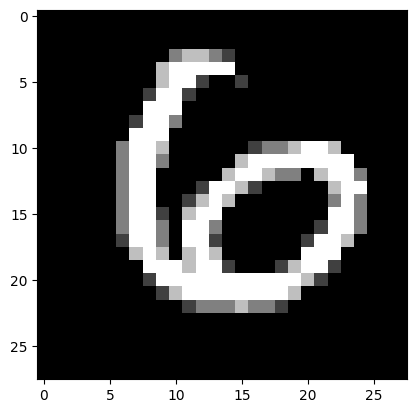

Prediction:  [6]
Label:  6


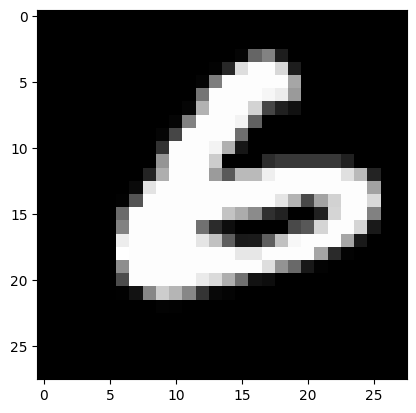

Prediction:  [2]
Label:  3


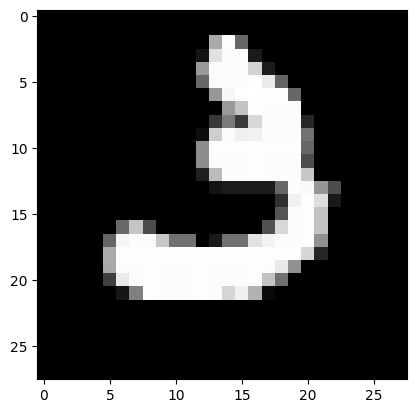

Prediction:  [2]
Label:  2


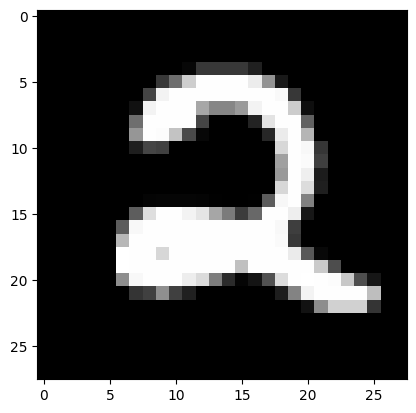

In [91]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)